In [1]:
# os: Operating System의 줄임말로, 운영체제에서 제공되는 여러 기능을 파이썬에서 사용할 수 있도록 함 (Ex. 디렉토리 경로 이동, 시스템 환경 변수 가져오기 등)
# urllib: URL 작업을 위한 여러 모듈을 모은 패키지. (Ex. urllib.request, urllib.parse, ...)
# cv2: OpenCV 라이브러리로, 실시간 컴퓨터 비전을 목적으로 한 프로그래밍 라이브러리
# numpy(NumPy): 행렬이나 대규모 다차원 배열을 쉽게 처리할 수 있도록 지원하는 라이브러리. 데이터 구조 외에도 수치 계산을 위해 효율적으로 구현된 기능을 제공
# pixellib: 이미지 및 비디오 segmentation을 수행하기 위한 라이브러리. 
# pixellib.semantic: segmentation 기법 중, semantic segmentation을 쉽게 사용할 수 있도록 만든 라이브러리
# matplotlib: 파이썬 프로그래밍 언어 및 수학적 확장 NumPy 라이브러리를 활용한 플로팅 라이브러리로, 데이터 시각화 도구
import os
import urllib
import cv2
import numpy as np
from pixellib.semantic import semantic_segmentation
from matplotlib import pyplot as plt
from PIL import Image

print('Import 완료')

Import 완료


(2944, 2208, 3)


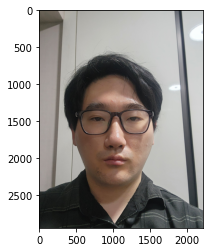

In [2]:
# os 모듈에 있는 getenv() 함수를 이용하여 읽고싶은 파일의 경로를 file_path에 저장
# 준비한 이미지 파일의 경로를 이용하여, 이미지 파일을 읽음
# cv2.imread(경로): 경로에 해당하는 이미지 파일을 읽어서 변수에 저장
img_path = os.getenv('HOME')+'/aiffel/human_segmentation/images/my_photo_02.jpg'  
img_orig = cv2.imread(img_path, cv2.IMREAD_UNCHANGED) 
print(img_orig.shape)

# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 이미지 색상 채널을 변경 (BGR 형식을 RGB 형식으로 변경)
# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시, 입력은 RGB(A) 데이터 혹은 2D 스칼라 데이터
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html
# plt.show(): 현재 열려있는 모든 figure를 표시 (여기서 figure는 이미지, 그래프 등)
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html
plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
plt.show()

처음에는 대체 무슨 이유인지 똑바로 서 있는 사진을 클라우드 쥬피터가 위와 같이 눕혀서 읽는 문제가 있었기에
사진을 오른쪽으로 90도 돌린 뒤 그 돌린 사진을 img_path에 저장하는 코드를 작성하였음.
굳이 돌린 사진을 저장까지 한 이유는 아래의 segmentAsPascalvoc() 함수가 외부 이미지 파일만 읽을 수 있기 때문.
문제가 해결되었으므로 아래의 코드는 주석 처리함.

In [3]:
'''
img_orig = cv2.rotate(img_orig, cv2.ROTATE_90_COUNTERCLOCKWISE)
print(img_orig.shape)

plt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))
plt.show()

cv2.imwrite(img_path, img_orig)
'''

'\nimg_orig = cv2.rotate(img_orig, cv2.ROTATE_90_COUNTERCLOCKWISE)\nprint(img_orig.shape)\n\nplt.imshow(cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB))\nplt.show()\n\ncv2.imwrite(img_path, img_orig)\n'

In [4]:
# 저장할 모델 파일의 경로와 이름을 결정
model_dir = os.getenv('HOME')+'/aiffel/human_segmentation/models' 
model_file = os.path.join(model_dir, 'deeplabv3_xception_tf_dim_ordering_tf_kernels.h5') 

# PixelLib가 제공하는 모델의 url
model_url = 'https://github.com/ayoolaolafenwa/PixelLib/releases/download/1.1/deeplabv3_xception_tf_dim_ordering_tf_kernels.h5' 

# urllib 패키지 내에 있는 request 모듈의 urlretrieve 함수를 이용해서 model_url에 있는 파일을 다운로드 해서 model_file 파일명으로 저장
urllib.request.urlretrieve(model_url, model_file)

('/aiffel/aiffel/human_segmentation/models/deeplabv3_xception_tf_dim_ordering_tf_kernels.h5',
 <http.client.HTTPMessage at 0x785593fea1c0>)

In [5]:
#PixelLib 라이브러리 에서 가져온 클래스를 가져와서 semantic segmentation을 수행하는 클래스 인스턴스를 만듬
model = semantic_segmentation()
# pascal voc에 대해 훈련된 예외 모델(model_file)을 로드하는 함수를 호출
model.load_pascalvoc_model(model_file)

In [6]:
# segmentAsPascalvoc() 수를 호출 하여 입력된 이미지를 분할, 분할 출력의 배열을 가져옴
# 분할은 pacalvoc 데이터로 학습된 모델을 이용
segvalues, output = model.segmentAsPascalvoc(img_path)

In [7]:
#pascalvoc 데이터의 라벨종류
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]
len(LABEL_NAMES)

21

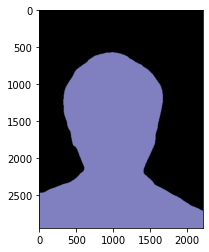

In [8]:
#segmentAsPascalvoc() 함수 를 호출하여 입력된 이미지를 분할한 뒤 나온 결과값 중 output을 matplotlib을 이용해 출력

plt.imshow(output)
plt.show()

In [9]:
segvalues # segmentAsPascalvoc() 함수를 호출하여 입력된 이미지를 분할한 뒤 나온 결과값 중 배열값을 출력

{'class_ids': array([ 0, 15]),
 'masks': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]])}

In [10]:
#segvalues에 있는 class_ids를 담겨있는 값을 통해 pascalvoc에 담겨있는 라벨을 출력
for class_id in segvalues['class_ids']:
    print(LABEL_NAMES[class_id])

background
person


In [11]:
# 아래 코드를 이해하지 않아도 좋습니다
# PixelLib에서 그대로 가져온 코드입니다
# 주목해야 할 것은 생성 코드 결과물이예요!

#컬러맵 만들기 
colormap = np.zeros((256, 3), dtype = int)
ind = np.arange(256, dtype=int)

for shift in reversed(range(8)):
    for channel in range(3):
        colormap[:, channel] |= ((ind >> channel) & 1) << shift
    ind >>= 3

colormap[:20] #생성한 20개의 컬러맵 출력

array([[  0,   0,   0],
       [128,   0,   0],
       [  0, 128,   0],
       [128, 128,   0],
       [  0,   0, 128],
       [128,   0, 128],
       [  0, 128, 128],
       [128, 128, 128],
       [ 64,   0,   0],
       [192,   0,   0],
       [ 64, 128,   0],
       [192, 128,   0],
       [ 64,   0, 128],
       [192,   0, 128],
       [ 64, 128, 128],
       [192, 128, 128],
       [  0,  64,   0],
       [128,  64,   0],
       [  0, 192,   0],
       [128, 192,   0]])

In [12]:
colormap[15] #컬러맵 15에 해당하는 배열 출력 (pacalvoc에 LABEL_NAMES 15번째인 사람)

array([192, 128, 128])

In [13]:
seg_color = (128,128,192) # 색상순서 변경 - colormap의 배열은 RGB 순이며 output의 배열은 BGR 순서로 채널 배치가 되어 있어서

(2944, 2208)


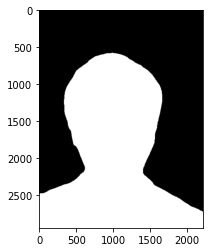

In [14]:
# output의 픽셀 별로 색상이 seg_color와 같다면 1(True), 다르다면 0(False)이 됩니다
# seg_color 값이 person으로 분류된 픽셀의 값이므로 사람이 있는 위치를 제외하고는 gray로 출력
# cmap 값을 변경하면 다른 색상으로 확인이 가능함
seg_map = np.all(output==seg_color, axis=-1) 
print(seg_map.shape) 
plt.imshow(seg_map, cmap='gray')
plt.show()

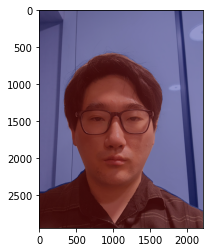

In [15]:
# 원본이미지를 img_show에 할당한뒤 이미지 사람이 있는 위치와 배경을 분리해서 표현한 color_mask 를 만든뒤 두 이미지를 합쳐서 출력
img_show = img_orig.copy()

# True과 False인 값을 각각 255과 0으로 바꿔주기
img_mask = seg_map.astype(np.uint8) * 255

# 255와 0을 적당한 색상으로 바꿔주기
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

# 원본 이미지와 마스트를 적당히 합쳐봅니다
# 0.6과 0.4는 두 이미지를 섞는 비율입니다.
img_show = cv2.addWeighted(img_show, 0.6, color_mask, 0.4, 0.0)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

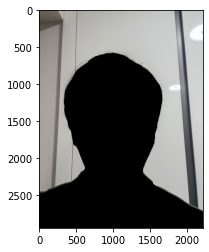

In [16]:
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경) 
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)

# cv2.bitwise_not(): 이미지가 반전됩니다. 배경이 0 사람이 255 였으나
# 연산을 하고 나면 배경은 255 사람은 0입니다.
img_bg_mask = cv2.bitwise_not(img_mask_color)

# img_orig와 img_bg_mask를 합성하여 인물 부분만 정확히 잘라냈는지 확인
img_bg = cv2.bitwise_and(img_orig, img_bg_mask)
plt.imshow(cv2.cvtColor(img_bg, cv2.COLOR_BGR2RGB))
plt.show()

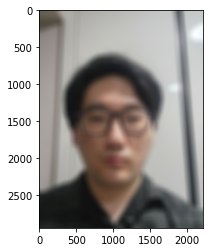

In [17]:
# blur 매개변수를 (100, 100) 으로 부여
img_orig_blur_100 = cv2.blur(img_orig, (100,100))

# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시한다.
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)   
plt.imshow(cv2.cvtColor(img_orig_blur_100, cv2.COLOR_BGR2RGB))
plt.show()

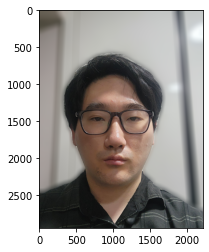

In [18]:
# np.where(조건, 참일때, 거짓일때)
# 세그멘테이션 마스크가 255인 부분만 원본 이미지 값을 가지고 오고 
# 아닌 영역은 블러된 이미지 값을 사용합니다.
img_concat_100 = np.where(img_mask_color==255, img_orig, img_orig_blur_100)
plt.imshow(cv2.cvtColor(img_concat_100, cv2.COLOR_BGR2RGB))
plt.show()

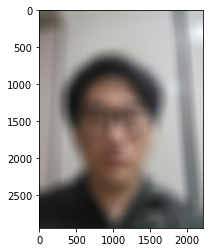

In [19]:
# blur 매개변수를 (200, 200) 으로 부여
img_orig_blur_200 = cv2.blur(img_orig, (200,200))

img_bg_blur_200 = cv2.bitwise_and(img_orig_blur_200, img_bg_mask)
plt.imshow(cv2.cvtColor(img_orig_blur_200, cv2.COLOR_BGR2RGB))
plt.show()

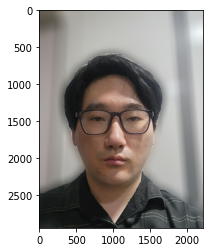

In [20]:
img_concat_200 = np.where(img_mask_color==255, img_orig, img_bg_blur_200)
plt.imshow(cv2.cvtColor(img_concat_200, cv2.COLOR_BGR2RGB))
plt.show()

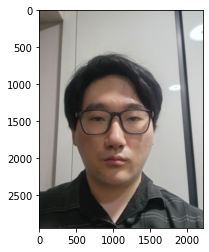

In [21]:
# blur 매개변수를 (13 13) 으로 부여
img_orig_blur_13 = cv2.blur(img_orig, (13,13))

img_bg_blur_13 = cv2.bitwise_and(img_orig_blur_13, img_bg_mask)
plt.imshow(cv2.cvtColor(img_orig_blur_13, cv2.COLOR_BGR2RGB))
plt.show()

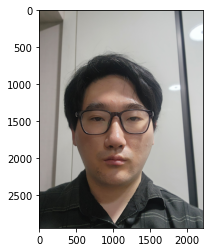

In [22]:
img_concat_13 = np.where(img_mask_color==255, img_orig, img_bg_blur_13)
plt.imshow(cv2.cvtColor(img_concat_13, cv2.COLOR_BGR2RGB))
plt.show()

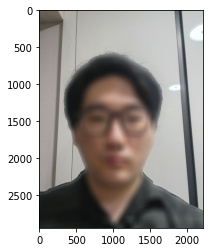

In [23]:
# 배경을 원본으로, 인물 사진을 블러로

img_concat_reversed = np.where(img_mask_color!=255, img_orig, img_orig_blur_100)
plt.imshow(cv2.cvtColor(img_concat_reversed, cv2.COLOR_BGR2RGB))
plt.show()

(720, 1080, 3)


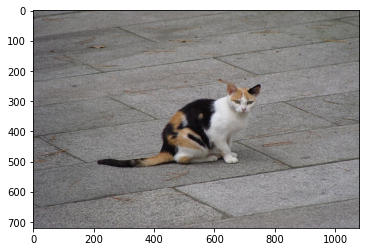

In [24]:
# 고양이 사진 로드

img_path_cat = os.getenv('HOME')+'/aiffel/human_segmentation/images/cat_photo.jpg'  
img_orig_cat = cv2.imread(img_path_cat, cv2.IMREAD_UNCHANGED) 

# 아래에서 로드할 배경사진에 맞춰 고양이 사진의 크기를 변경
img_orig_cat = cv2.resize(img_orig_cat, (1080, 720))

print(img_orig_cat.shape) 

plt.imshow(cv2.cvtColor(img_orig_cat, cv2.COLOR_BGR2RGB))
plt.show()

(720, 1080, 3)


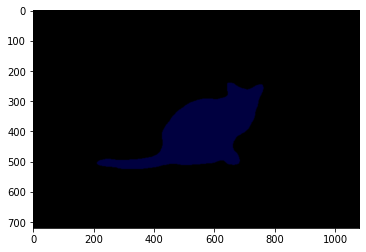

In [25]:
segvalues_cat, output_cat = model.segmentAsPascalvoc(img_path_cat)

# 아래에서 로드할 배경사진에 맞춰 고양이 사진의 크기를 변경
output_cat = cv2.resize(output_cat, (1080, 720))

print(output_cat.shape) 

plt.imshow(output_cat)
plt.show()

In [26]:
for class_id in segvalues_cat['class_ids']:
    print(LABEL_NAMES[class_id])

background
cat


In [27]:
# 컬러맵 8에 해당하는 배열 출력 (pacalvoc에 LABEL_NAMES  8번째인 고양이)

colormap[8]

array([64,  0,  0])

In [28]:
# cv2 image는 색깔 정보를 RGB가 아닌 BGR로 저장하기 때문에 색깔 튜플의 순서를 바꿈

seg_color_cat = (0,0,64)

(720, 1080)


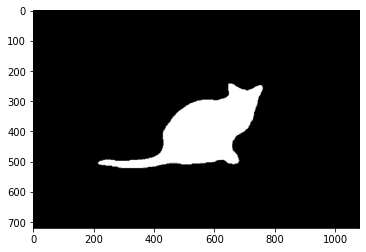

In [29]:
# output의 픽셀 별로 색상이 seg_color와 같다면 1(True), 다르다면 0(False)이 됩니다
# seg_color 값이 person을 값이 므로 사람이 있는 위치를 제외하고는 gray로 출력
# cmap 값을 변경하면 다른 색상으로 확인이 가능함
seg_map_cat = np.all(output_cat==seg_color_cat, axis=-1) 
print(seg_map_cat.shape) 
plt.imshow(seg_map_cat, cmap='gray')
plt.show()

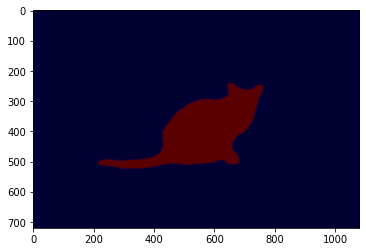

In [30]:
# 원본이미지를 img_show에 할당한뒤 이미지 사람이 있는 위치와 배경을 분리해서 표현한 color_mask 를 만든뒤 두 이미지를 합쳐서 출력
img_show_cat= output_cat.copy()

# True과 False인 값을 각각 255과 0으로 바꿔줍니다
img_mask_cat = seg_map_cat.astype(np.uint8) * 255

# 255와 0을 적당한 색상으로 바꿔봅니다
color_mask_cat = cv2.applyColorMap(img_mask_cat, cv2.COLORMAP_JET)

# 원본 이미지와 마스트를 적당히 합쳐봅니다
# 0.6과 0.4는 두 이미지를 섞는 비율입니다.
img_show_cat = cv2.addWeighted(img_show_cat, 0.6, color_mask_cat, 0.4, 0.0)

plt.imshow(cv2.cvtColor(img_show_cat, cv2.COLOR_BGR2RGB))
plt.show()

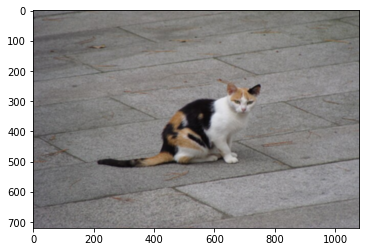

In [31]:
# blur 매개변수를 (5, 5) 으로 부여
img_orig_cat_blur_5 = cv2.blur(img_orig_cat, (5,5))

# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시한다.
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)   
plt.imshow(cv2.cvtColor(img_orig_cat_blur_5, cv2.COLOR_BGR2RGB))
plt.show()

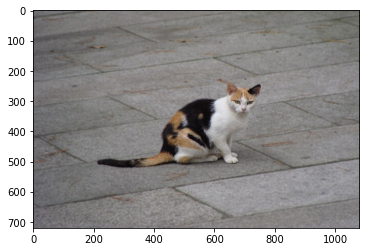

In [32]:
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경) 
img_mask_cat_color = cv2.cvtColor(img_mask_cat, cv2.COLOR_GRAY2BGR)

# np.where(조건, 참일때, 거짓일때)
# 세그멘테이션 마스크가 255인 부분만 원본 이미지 값을 가지고 오고 
# 아닌 영역은 블러된 이미지 값을 사용합니다.
img_concat_cat_5 = np.where(img_mask_cat_color==255, img_orig_cat, img_orig_cat_blur_5)
# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시한다.
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니 
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
plt.imshow(cv2.cvtColor(img_concat_cat_5, cv2.COLOR_BGR2RGB))
plt.show()

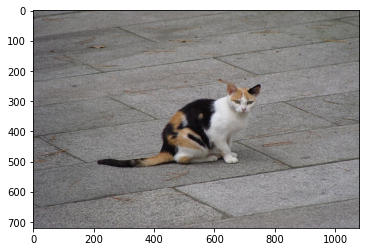

In [33]:
plt.imshow(cv2.cvtColor(img_orig_cat, cv2.COLOR_BGR2RGB))
plt.show()

(720, 1080, 3)


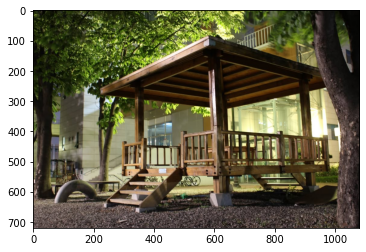

In [34]:
img_path_bg = os.getenv('HOME')+'/aiffel/human_segmentation/images/my_background.jpg'  
img_orig_bg = cv2.imread(img_path_bg, cv2.IMREAD_UNCHANGED)
print(img_orig_bg.shape)
plt.imshow(cv2.cvtColor(img_orig_bg, cv2.COLOR_BGR2RGB))
plt.show()

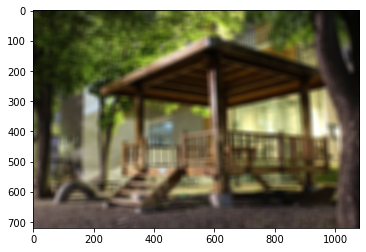

In [35]:
img_orig_bg_blur_100= cv2.blur(img_orig_bg, (20,20))
plt.imshow(cv2.cvtColor(img_orig_bg_blur_100, cv2.COLOR_BGR2RGB))
plt.show()

(720, 1080)


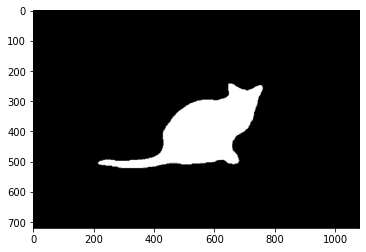

In [36]:
# output의 픽셀 별로 색상이 seg_color와 같다면 1(True), 다르다면 0(False)이 됩니다
# seg_color 값이 person을 값이 므로 사람이 있는 위치를 제외하고는 gray로 출력
# cmap 값을 변경하면 다른 색상으로 확인이 가능함
seg_map_cat = np.all(output_cat==seg_color_cat, axis=-1) 
print(seg_map_cat.shape) 
plt.imshow(seg_map_cat, cmap='gray')
plt.show()

# True과 False인 값을 각각 255과 0으로 바꿔주기
img_mask_cat = seg_map_cat.astype(np.uint8) * 255
img_mask_cat_color = cv2.cvtColor(img_mask_cat, cv2.COLOR_GRAY2BGR)

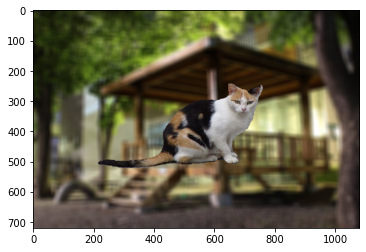

In [37]:
# np.where(조건, 참일때, 거짓일때)
# 세그멘테이션 마스크가 255인 부분만 원본 이미지 값을 가지고 오고 
# 아닌 영역은 블러된 이미지 값을 사용합니다.
img_concat_cat_100 = np.where(img_mask_cat_color==255, img_orig_cat, img_orig_bg_blur_100)
# plt.imshow(): 저장된 데이터를 이미지의 형식으로 표시한다.
# cv2.cvtColor(입력 이미지, 색상 변환 코드): 입력 이미지의 색상 채널을 변경
# cv2.COLOR_BGR2RGB: 원본이 BGR 순서로 픽셀을 읽다보니 
# 이미지 색상 채널을 변경해야함 (BGR 형식을 RGB 형식으로 변경)
plt.imshow(cv2.cvtColor(img_concat_cat_100, cv2.COLOR_BGR2RGB))
plt.show()

총 회고

1. 인물 사진의 배경을 흐리게 만드는 합성을 할 때, blur 값을 200으로 주었을 때 인물과 배경의 경계선이 약간 부자연스럽게 나오는 문제가 있었음.
2. 그 외에는 사진 합성 과정에서 별다른 문제점이 발견되지는 않은 것으로 판단함.